In [1]:
#Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#loading both of the datasets
round_stats = pd.read_csv('/content/round_stats_cleaned.csv')
team_matches = pd.read_csv('/content/team_matches_home_away_raw - team_matches_home_away_raw.csv.csv')

In [3]:
#As I cleaned the round_stats dataset in previous notebook so we donot need to clean that again just checking again
round_stats.head(2)

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,hawthorn hawks,1994,17.0,richmond tigers,21,W,34.0,5.0,4.0,...,0.0,0.0,0.0,0.0,0.0,45552.0,1994-08-14,36.0,0.0,28.0
1,614897,geelong cats,2024,1.0,st kilda saints,1,W,7.0,5.0,0.0,...,0.0,1.0,0.0,0.0,26.0,44356.0,2024-03-16,23.0,0.0,8.0


In [4]:
round_stats.shape

(217568, 36)

In [5]:
round_stats.columns

Index(['id', 'team', 'year', 'career_game_count', 'opponent', 'round',
       'result', 'jersey_num', 'kicks', 'marks', 'handballs', 'disposals',
       'goals', 'behinds', 'hit_outs', 'tackles', 'rebound_50s', 'inside_50s',
       'clearances', 'clangers', 'free_kicks_for', 'free_kicks_against',
       'brownlow_votes', 'contested_possessions', 'uncontested_possessions',
       'contested_marks', 'marks_inside_50', 'one_percenters', 'bounces',
       'goal_assist', 'percentage_of_game_played', 'player_id', 'match_date',
       'fantasy_points', 'score', 'margin'],
      dtype='object')

In [9]:
round_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217568 entries, 0 to 217567
Data columns (total 36 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   id                         217568 non-null  int64         
 1   team                       217568 non-null  object        
 2   year                       217568 non-null  int64         
 3   career_game_count          217568 non-null  float64       
 4   opponent                   217568 non-null  object        
 5   round                      217568 non-null  object        
 6   result                     217568 non-null  object        
 7   jersey_num                 217568 non-null  float64       
 8   kicks                      217568 non-null  float64       
 9   marks                      217568 non-null  float64       
 10  handballs                  217568 non-null  float64       
 11  disposals                  217568 non-null  float64 

In [10]:
#now confirming there are no duplicated in round_stat
round_stats.duplicated().sum()

np.int64(0)

In [11]:
#showing there are no null values in round_stats
round_stats.isnull().sum()

,0
id,0
team,0
year,0
career_game_count,0
opponent,0
round,0
result,0
jersey_num,0
kicks,0
marks,0


In [12]:
#checking teams are ok there is no errors like of capitalization and appearing 2 times
round_stats['team'].value_counts()

,count
team,
geelong cats,13139
st kilda saints,13084
west coast eagles,13068
essendon bombers,13066
north melbourne kangaroos,13014
adelaide crows,12978
richmond tigers,12972
carlton blues,12944
collingwood magpies,12878


In [13]:
round_stats['opponent'].value_counts()

,count
opponent,
west coast eagles,13008
geelong cats,12990
sydney swans,12958
hawthorn hawks,12956
carlton blues,12954
collingwood magpies,12925
north melbourne kangaroos,12921
western bulldogs,12913
melbourne demons,12872


In [14]:
#now lets move to the next dataset which is raw and we have to clean that
team_matches.head(2)

,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds
0,15807,Hawthorn Hawks,QF,1994-09-10,1994,A,North Melbourne Kangaroos,4.5 5.7 10.11 13.13 13.13 13.13,91,2.3 6.12 9.12 12.19 13.23 15.24,114,L,23,Waverley Park,38223.0,13,13,15,24
1,15808,North Melbourne Kangaroos,QF,1994-09-10,1994,H,Hawthorn Hawks,2.3 6.12 9.12 12.19 13.23 15.24,114,4.5 5.7 10.11 13.13 13.13 13.13,91,W,6,Waverley Park,38223.0,15,24,13,13


In [15]:
team_matches.tail(2)

,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds
15806,10295,Adelaide Crows,6,1994-04-30,1994,A,brisbane bears,1.3 4.8 10.10 18.13,121,3.2 8.5 13.6 17.8,110,W,11,The Gabba,9457.0,18,13,17,8
15807,10343,Adelaide Crows,10,1996-06-09,1996,H,west coast eagles,1.1 8.3 9.5 11.10,76,5.5 9.8 18.11 19.16,130,L,-54,AAMI Stadium\n,43398.0,11,10,19,16


In [16]:
#now checking the shape
team_matches.shape

(15808, 19)

In [17]:
#checking column names
team_matches.columns

Index(['id', 'team_name', 'round', 'match_date', 'year', 'home_away',
       'opponent', 'team_quarter_scores', 'team_score',
       'opponent_quarter_scores', 'opponent_score', 'result', 'margin',
       'venue', 'crowd', 'team_goals_kicked', 'team_behinds',
       'opponent_goals_kicked', 'opponent_behinds'],
      dtype='object')

In [18]:
#checking datatypes of all columns
team_matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15808 entries, 0 to 15807
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       15808 non-null  int64  
 1   team_name                15808 non-null  object 
 2   round                    15808 non-null  object 
 3   match_date               15808 non-null  object 
 4   year                     15808 non-null  int64  
 5   home_away                15808 non-null  object 
 6   opponent                 15808 non-null  object 
 7   team_quarter_scores      15808 non-null  object 
 8   team_score               15808 non-null  int64  
 9   opponent_quarter_scores  15808 non-null  object 
 10  opponent_score           15808 non-null  int64  
 11  result                   15808 non-null  object 
 12  margin                   15808 non-null  int64  
 13  venue                    15808 non-null  object 
 14  crowd                 

In [19]:
#as the match date column is str so we have to convert that to date and time
team_matches['match_date'] = pd.to_datetime(team_matches['match_date'])

In [20]:
#now checking the conversion
team_matches['match_date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 15808 entries, 0 to 15807
Series name: match_date
Non-Null Count  Dtype         
--------------  -----         
15808 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 123.6 KB


In [21]:
team_matches.describe()

,id,match_date,year,team_score,opponent_score,margin,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds
count,15808.000000,15808,15808.000000,15808.000000,15808.000000,15808.000000,15410.000000,15808.000000,15808.000000,15808.000000,15808.000000
mean,7904.500000,2005-10-05 13:18:53.198380672,2005.303517,92.323064,92.323064,0.001835,32522.293446,13.398406,11.932629,13.398406,11.932629
min,1.000000,1983-03-26 00:00:00,1983.000000,13.000000,13.000000,-186.000000,1241.000000,1.000000,1.000000,1.000000,1.000000
25%,3952.750000,1995-07-08 18:00:00,1995.000000,71.000000,71.000000,-30.000000,20031.000000,10.000000,9.000000,10.000000,9.000000
50%,7904.500000,2006-05-12 12:00:00,2006.000000,90.000000,90.000000,0.000000,29814.000000,13.000000,12.000000,13.000000,12.000000
75%,11856.250000,2016-05-21 00:00:00,2016.000000,110.000000,110.000000,30.000000,40844.000000,16.000000,14.000000,16.000000,14.000000
max,15808.000000,2025-09-27 00:00:00,2025.000000,239.000000,239.000000,186.000000,110332.000000,37.000000,31.000000,37.000000,31.000000
std,4563.520863,NaN,12.202924,29.581855,29.581855,44.771226,17607.923243,4.717789,4.003741,4.717789,4.003741


In [22]:
#for categorical columns we use because it gives us unique values, frequent values and top as well as count
team_matches.describe(include='object')

,team_name,round,home_away,opponent,team_quarter_scores,opponent_quarter_scores,result,venue
count,15808,15808,15808,15808,15808,15808,15808,15808
unique,40,30,2,40,15750,15750,3,64
top,Hawthorn Hawks,7,A,Hawthorn Hawks,2.5 3.10 5.14 9.17,4.1 7.3 8.6 11.8,L,Melbourne Cricket Ground
freq,968,684,7904,864,2,2,7839,3806


In [23]:
#Checking the Missing Values
team_matches.isnull().sum()

,0
id,0
team_name,0
round,0
match_date,0
year,0
home_away,0
opponent,0
team_quarter_scores,0
team_score,0
opponent_quarter_scores,0


<Axes: >

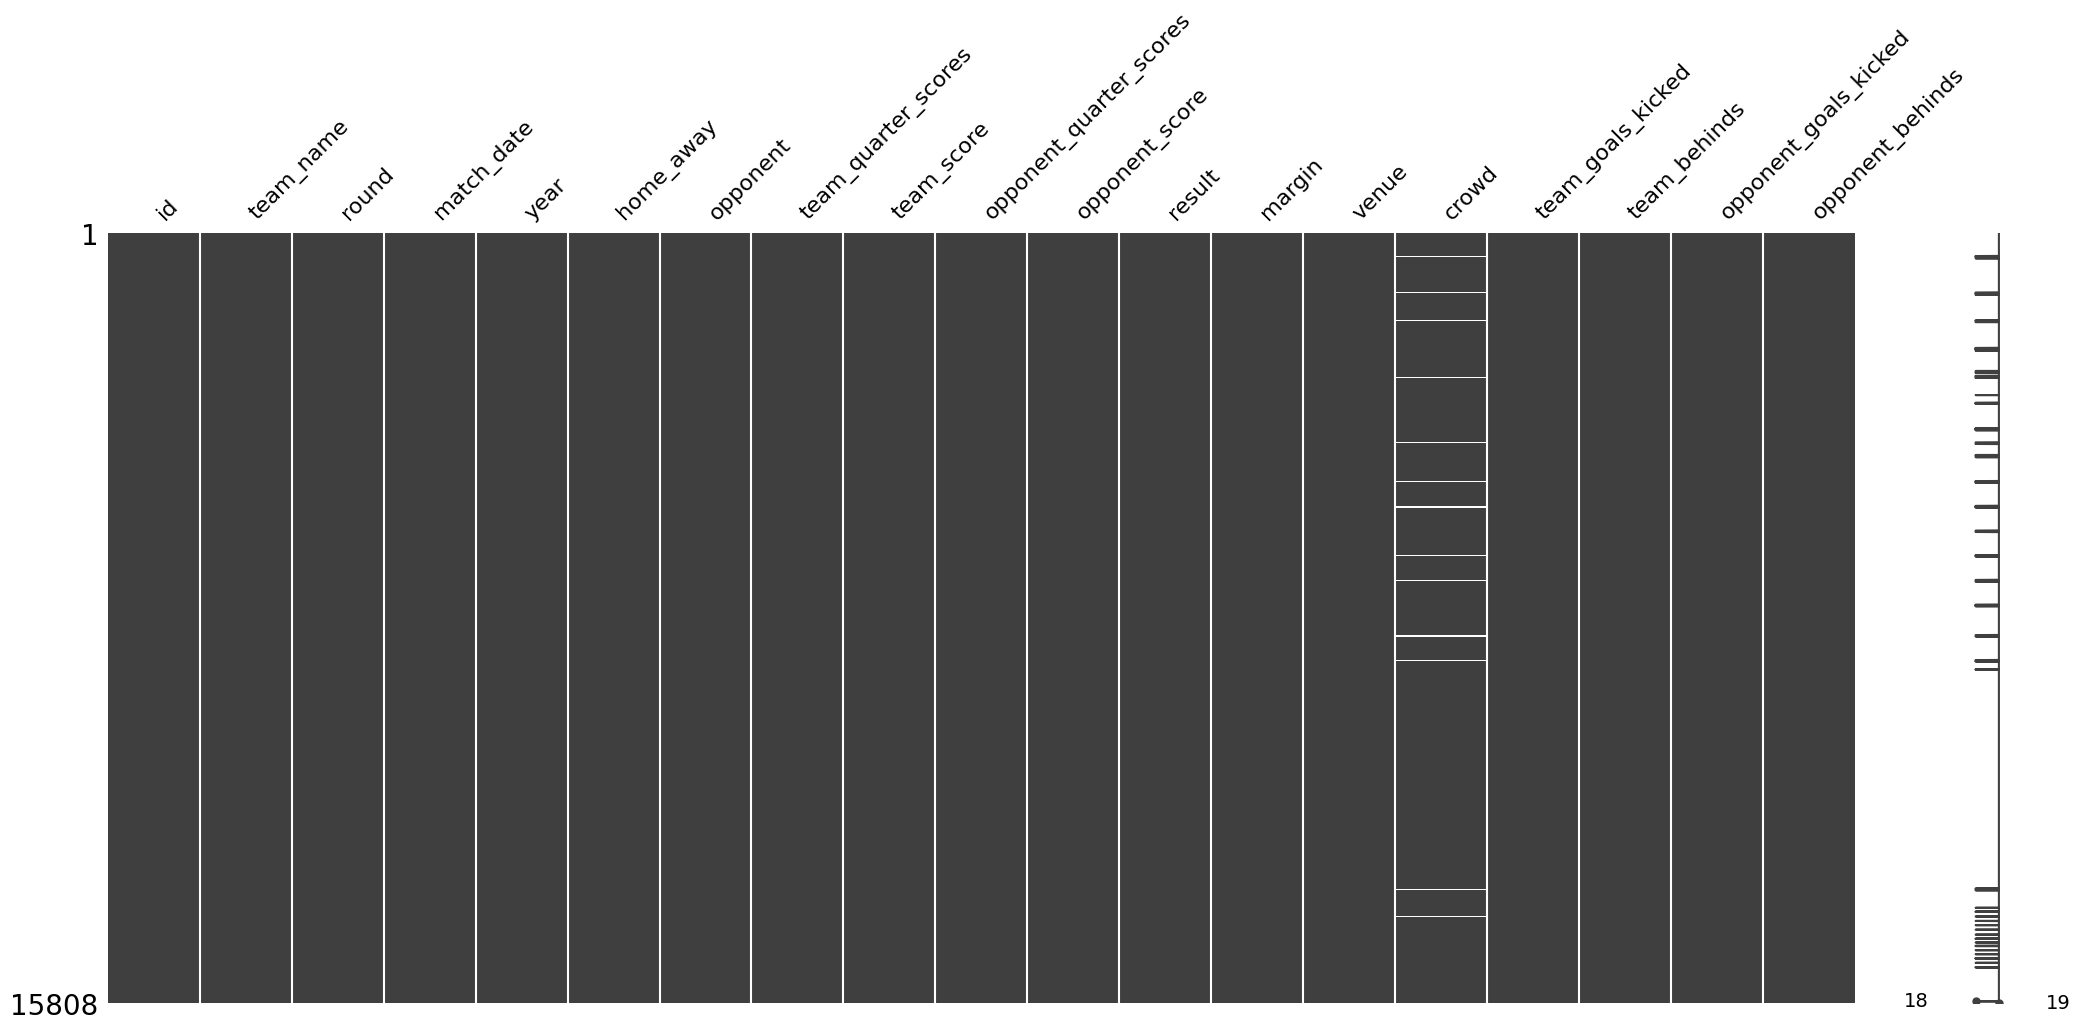

In [24]:
#visualizing the missing values
import missingno as msno
msno.matrix(team_matches)

In [25]:
#checking the perccentage of missing values in crowd column
missing_percentage = (team_matches['crowd'].isnull().sum() / len(team_matches)) * 100
print(f"Percentage of missing values in 'crowd' column: {missing_percentage:.2f}%")

Percentage of missing values in 'crowd' column: 2.52%


In [26]:
#looking at rows which have these missing values
team_matches[team_matches['crowd'].isnull()]

,id,team_name,round,match_date,year,home_away,opponent,team_quarter_scores,team_score,opponent_quarter_scores,opponent_score,result,margin,venue,crowd,team_goals_kicked,team_behinds,opponent_goals_kicked,opponent_behinds
473,10078,W. Bulldogs,1,2020-03-20,2020,H,Collingwood Magpies,1.0 4.0 5.2 5.4,34,5.2 8.6 10.7 13.8,86,L,-52,Marvel Stadium,NaN,5,4,13,8
474,10079,W. Bulldogs,2,2020-06-14,2020,A,St Kilda Saints,2.4 3.4 5.6 7.7,49,3.1 7.3 12.4 14.4,88,L,-39,Marvel Stadium,NaN,7,7,14,4
475,10081,W. Bulldogs,4,2020-06-25,2020,A,Sydney Swans,3.2 6.3 7.4 10.7,67,0.1 1.3 2.8 5.9,39,W,28,Sydney Cricket Ground,NaN,10,7,5,9
479,10082,W. Bulldogs,5,2020-07-04,2020,H,North Melbourne Kangaroos,2.2 5.5 10.6 13.9,87,1.2 2.3 3.5 5.8,38,W,49,Marvel Stadium,NaN,13,9,5,8
480,10083,W. Bulldogs,6,2020-07-12,2020,A,Carlton Blues,2.1 5.2 7.6 7.9,51,5.2 8.5 10.6 16.7,103,L,-52,People First Stadium,NaN,7,9,16,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15071,9492,West Coast Eagles,4,2020-06-27,2020,A,port adelaide power,1.2 2.4 5.4 6.5,41,4.4 6.7 10.11 13.11,89,L,-48,People First Stadium,NaN,6,5,13,11
15074,9525,West Coast Eagles,20,2021-07-31,2021,A,collingwood magpies,0.4 1.5 2.7 6.9,45,4.1 10.1 11.4 14.6,90,L,-45,Melbourne Cricket Ground,NaN,6,9,14,6
15773,471,Adelaide Crows,11,2020-08-11,2020,H,collingwood magpies,2.1 3.4 3.8 5.8,38,1.0 2.1 7.1 10.2,62,L,-24,Adelaide Oval,NaN,5,8,10,2
15774,473,Adelaide Crows,13,2020-08-23,2020,H,geelong cats,1.3 3.4 5.6 5.7,37,3.2 4.5 6.9 9.11,65,L,-28,Adelaide Oval,NaN,5,7,9,11


In [27]:
#checking for which year the crowd values are zero
team_matches[team_matches['crowd'].isnull()].groupby('year').size()

,0
year,
2020,324
2021,74


#After checking online we found that the majority missing values are from 2020-21 because there were zero crowd matches because of Covid 19 Pandemic
I have also attached the Screen shot
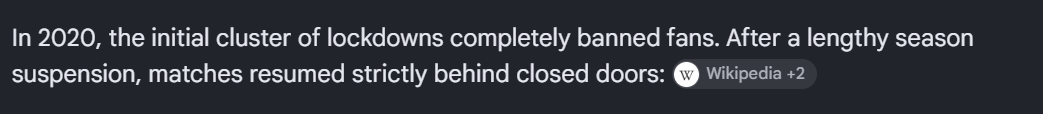

#2021 matches whose values are missing are also among these dates

Here is the Screenshot
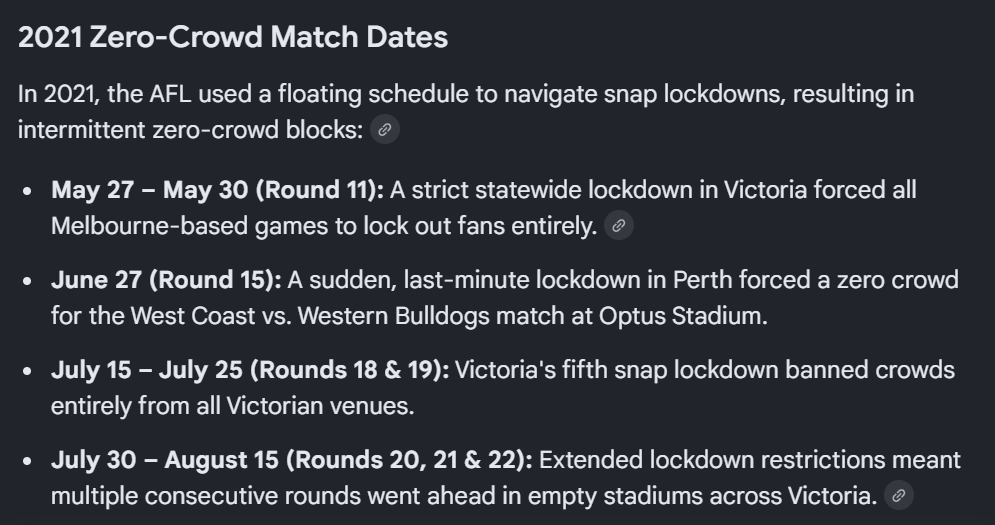

In [28]:
#after the above research we can impute the missing values of crowd column with zero
team_matches['crowd'] = team_matches['crowd'].fillna(0)
team_matches['crowd'].isnull().sum()

np.int64(0)

In [29]:
# now we have handeled all the missing values
#lets check duplicates
team_matches.duplicated().sum()

np.int64(0)

In [30]:
#checking unique values
team_matches.nunique()

,0
id,15808
team_name,40
round,30
match_date,3347
year,43
home_away,2
opponent,40
team_quarter_scores,15750
team_score,204
opponent_quarter_scores,15750


In [31]:
#checking the team names are ok and there is no capital and small letter issue which makes them different
team_matches['team_name'].value_counts()

,count
team_name,
Hawthorn Hawks,968
Geelong Cats,958
Essendon Bombers,941
Sydney Swans,936
W. Bulldogs,934
Carlton Blues,932
North Melbourne Kangaroos,930
Collingwood Magpies,929
Melbourne Demons,922


In [32]:
#we can see that same name appears twice because of spacing issue so we have to fix it
#we standardize text
#removing spaces
team_matches['team_name']=team_matches['team_name'].str.strip()

In [33]:
#converting to lower case so this issue doesnot appear again
team_matches['team_name'] = team_matches['team_name'].str.lower()


In [34]:
#now the issue is fixed
team_matches['team_name'].value_counts()

,count
team_name,
geelong cats,1013
hawthorn hawks,1007
sydney swans,998
collingwood magpies,996
essendon bombers,989
carlton blues,983
w. bulldogs,982
north melbourne kangaroos,982
melbourne demons,980


In [35]:
# Standardizing opponent names by stripping spaces and converting to lower case
team_matches['opponent'] = team_matches['opponent'].str.strip().str.lower()

In [36]:
#also checking the oponent colum
team_matches['opponent'].value_counts()

,count
opponent,
geelong cats,1013
hawthorn hawks,1007
sydney swans,998
collingwood magpies,996
essendon bombers,989
carlton blues,983
north melbourne kangaroos,982
western bulldogs,982
melbourne demons,980


In [37]:
#now checking that team names match or not for both datasets
unique_round_teams = sorted(round_stats['team'].unique())
unique_match_teams = sorted(team_matches['team_name'].unique())

print(f"Unique teams in round_stats: {len(unique_round_teams)}")
print(f"Unique teams in team_matches: {len(unique_match_teams)}")

# Check if there are teams in one but not the other
diff = set(unique_round_teams).symmetric_difference(set(unique_match_teams))
if diff:
    print(f"Differences found: {diff}")
else:
    print("Team names match perfectly between both datasets.")

Unique teams in round_stats: 20
Unique teams in team_matches: 20
Differences found: {'western bulldogs', 'w. bulldogs'}


In [38]:
# Fix naming discrepancy for Western Bulldogs
team_matches['team_name'] = team_matches['team_name'].replace('w. bulldogs', 'western bulldogs')
team_matches['opponent'] = team_matches['opponent'].replace('w. bulldogs', 'western bulldogs')

# Verify the fix
print(f"Unique teams in team_matches now: {len(team_matches['team_name'].unique())}")
print(f"Difference now: {set(round_stats['team'].unique()).symmetric_difference(set(team_matches['team_name'].unique()))}")

Unique teams in team_matches now: 20
Difference now: set()


In [39]:
from google.colab import files

# Exporting the cleaned dataframes to CSV files
round_stats.to_csv('round_stats_clean.csv', index=False)
team_matches.to_csv('team_matches_home_away_cleaned.csv', index=False)

# Triggering the downloads
files.download('round_stats_clean.csv')
files.download('team_matches_home_away_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Relationship Discovery and Composite Key Reasoning

In [40]:
# 1. Relationship Discovery

# Identify common fields
common_cols = set(round_stats.columns).intersection(set(team_matches.columns))
print(f"Directly matching column names: {common_cols}")
print(f"Logically matching columns: (round_stats.team -> team_matches.team_name), (round_stats.opponent -> team_matches.opponent)")

# Reasoning for composite key:
# A single key like 'year' or 'round' is repeated many times.
# To uniquely identify a match and its stats, we must use a composite key:
# ['match_date', 'team', 'opponent'] (where 'team' matches 'team_name' in the other frame).

# Verify uniqueness of the proposed composite key in team_matches
key_check = team_matches.duplicated(subset=['match_date', 'team_name', 'opponent']).sum()
print(f"Duplicate matches found using composite key in team_matches: {key_check}")

Directly matching column names: {'margin', 'match_date', 'opponent', 'result', 'round', 'id', 'year'}
Logically matching columns: (round_stats.team -> team_matches.team_name), (round_stats.opponent -> team_matches.opponent)
Duplicate matches found using composite key in team_matches: 0


###  Step 2: Context Enrichment - Detailed Merge and Validation
We will now merge the datasets using a left join. This will enrich each player's performance record with match-level information like venue, crowd size, and specific team scores.

In [53]:
# Select specific columns for enrichment ---
# We focus on home_away, venue, and crowd as requested, plus the keys for merging.
enrichment_cols = ['match_date', 'team_name', 'home_away', 'venue', 'crowd']


In [54]:
# Perform the Merge ---
# We merge round_stats with the subset of team_matches.
# We use a 'left' join to preserve all player-level records from round_stats.
merged_df = pd.merge(
    round_stats,
    team_matches[enrichment_cols],
    left_on=['match_date', 'team'],
    right_on=['match_date', 'team_name'],
    how='left'
)

In [55]:
# Remove the redundant team_name column generated by the merge
merged_df.drop(columns=['team_name'], inplace=True)

In [56]:
# 1. Row Count Validation: The number of rows must match the original round_stats
rows_match = len(merged_df) == len(round_stats)
print(f"Row count consistency: {'PASSED' if rows_match else 'FAILED'} ({len(merged_df)} rows)")

Row count consistency: PASSED (217568 rows)


In [57]:
# 2. Missing Value Validation: Ensure 'home_away', 'venue', and 'crowd' were actually added
missing_venue = merged_df['venue'].isnull().sum()
missing_home_away = merged_df['home_away'].isnull().sum()
missing_crowd = merged_df['crowd'].isnull().sum()

print(f"Missing values in 'venue': {missing_venue}")
print(f"Missing values in 'home_away': {missing_home_away}")
print(f"Missing values in 'crowd': {missing_crowd}")

if missing_venue == 0 and missing_home_away == 0:
    print("\nSUCCESS: The datasets have been merged and enriched correctly.")
else:
    print("\nWARNING: Some records did not match. Please verify date and team name formats.")

Missing values in 'venue': 0
Missing values in 'home_away': 0
Missing values in 'crowd': 0

SUCCESS: The datasets have been merged and enriched correctly.


In [58]:
# Display enriched dataset sample
display(merged_df.head(5))

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin,home_away,venue,crowd
0,556392,hawthorn hawks,1994,17.0,richmond tigers,21,W,34.0,5.0,4.0,...,0.0,0.0,45552.0,1994-08-14,36.0,0.0,28.0,A,Melbourne Cricket Ground,52562.0
1,614897,geelong cats,2024,1.0,st kilda saints,1,W,7.0,5.0,0.0,...,0.0,26.0,44356.0,2024-03-16,23.0,0.0,8.0,H,GMHBA Stadium,39352.0
2,583553,essendon bombers,1999,97.0,adelaide crows,10,W,6.0,14.0,5.0,...,0.0,0.0,45955.0,1999-06-04,67.0,0.0,48.0,A,AAMI Stadium,39389.0
3,590676,western bulldogs,1994,36.0,st kilda saints,21,W,35.0,12.0,10.0,...,0.0,0.0,45656.0,1994-08-13,81.0,0.0,45.0,A,Waverley Park\n,14653.0
4,582473,richmond tigers,1997,113.0,melbourne demons,10,L,41.0,4.0,2.0,...,0.0,0.0,45929.0,1997-05-31,32.0,0.0,-25.0,H,Melbourne Cricket Ground,28879.0


# Merge Validation: Checking for Unmatched Records

In [60]:
# 1. Identify records that didn't find a match
# Since 'venue' and 'home_away' and crowd come only from team_matches, a null value indicates a failed join.
unmatched_count = merged_df['venue'].isnull().sum()
percent_unmatched = (unmatched_count / len(merged_df)) * 100
print(f"Total unmatched player records: {unmatched_count}")
print(f"Percentage unmatched: {percent_unmatched:.2f}%")

Total unmatched player records: 0
Percentage unmatched: 0.00%


In [61]:
unmatched_count=merged_df['home_away'].isnull().sum()
percent = (unmatched_count / len(merged_df)) * 100
print(f"Total unmatched player records: {unmatched_count}")
print(f"Percentage unmatched: {percent_unmatched:.2f}%")

Total unmatched player records: 0
Percentage unmatched: 0.00%


In [62]:
unmatched_count=merged_df['crowd'].isnull().sum()
percent = (unmatched_count / len(merged_df)) * 100
print(f"Total unmatched player records: {unmatched_count}")
print(f"Percentage unmatched: {percent_unmatched:.2f}%")

Total unmatched player records: 0
Percentage unmatched: 0.00%


# Merge Validation: Checking for Duplicated Records

In [65]:
# 1. Calculate duplicates in the merged dataset
duplicate_count = merged_df.duplicated().sum()
print(f"Total duplicated rows in merged_df: {duplicate_count}")

Total duplicated rows in merged_df: 0


In [66]:
# 2. Check if the number of rows increased unexpectedly
# Since it was a left join on player stats, the row count should ideally match round_stats
row_diff = len(merged_df) - len(round_stats)

print(f"Total duplicated rows found: {duplicate_count}")
print(f"Difference in row count (Merged vs Original): {row_diff}")

Total duplicated rows found: 0
Difference in row count (Merged vs Original): 0


# 3. Explanation of findings
    The merge is clean. No duplicate records were introduced
    and the player-level granularity of the original dataset has been preserved.
    This confirms the composite keys were unique in the match metadata dataset.

#Verification that the number of player records remains unchanged.

In [67]:
# Detailed Verification: Player Record Integrity

# 1. Shape Comparison
original_rows = round_stats.shape[0]
merged_rows = merged_df.shape[0]

print(f"--- Row Count Consistency ---")
print(f"Original player records (round_stats): {original_rows}")
print(f"Enriched player records (merged_df):  {merged_rows}")
print(f"Net Change: {merged_rows - original_rows}")

--- Row Count Consistency ---
Original player records (round_stats): 217568
Enriched player records (merged_df):  217568
Net Change: 0


In [68]:
# 2. Duplicate Key Check
# We check if the combination of player_id and match_date is still unique
# This ensures no player has multiple entries for the same match due to join issues.
duplicate_player_matches = merged_df.duplicated(subset=['player_id', 'match_date']).sum()

print(f"\n--- Granularity Check ---")
print(f"Duplicate player-match entries: {duplicate_player_matches}")


--- Granularity Check ---
Duplicate player-match entries: 0



    VERIFICATION SUCCESSFUL: The dataset maintains exact player-level granularity.

    Implication: The merge was a perfect 1-to-1 mapping for each player record.

#Contextual Analysis

In [69]:
# Performance Analysis: Home vs Away
# Selecting key performance indicators (KPIs) to compare
kpis = ['disposals', 'goals', 'fantasy_points', 'marks', 'tackles']

In [70]:
# Grouping by 'home_away' and calculating the mean for each KPI
home_away_analysis = merged_df.groupby('home_away')[kpis].mean()

In [71]:
# Adding a count column to see the distribution of records
home_away_analysis['sample_size'] = merged_df['home_away'].value_counts()

print("--- Average Player Performance: Home vs Away ---")
display(home_away_analysis)

--- Average Player Performance: Home vs Away ---


,disposals,goals,fantasy_points,marks,tackles,sample_size
home_away,,,,,,
A,14.701294,0.575295,64.146378,3.899401,2.348541,108739
H,15.166592,0.630889,66.524676,4.045714,2.377951,108829


In [72]:
# Calculating the percentage difference
diff = ((home_away_analysis.loc['H'] - home_away_analysis.loc['A']) / home_away_analysis.loc['A']) * 100

print("\n--- Percentage Advantage (Home over Away) ---")
for kpi in kpis:
    print(f"{kpi.replace('_', ' ').title()}: {diff[kpi]:.2f}%")


--- Percentage Advantage (Home over Away) ---
Disposals: 3.17%
Goals: 9.66%
Fantasy Points: 3.71%
Marks: 3.75%
Tackles: 1.25%


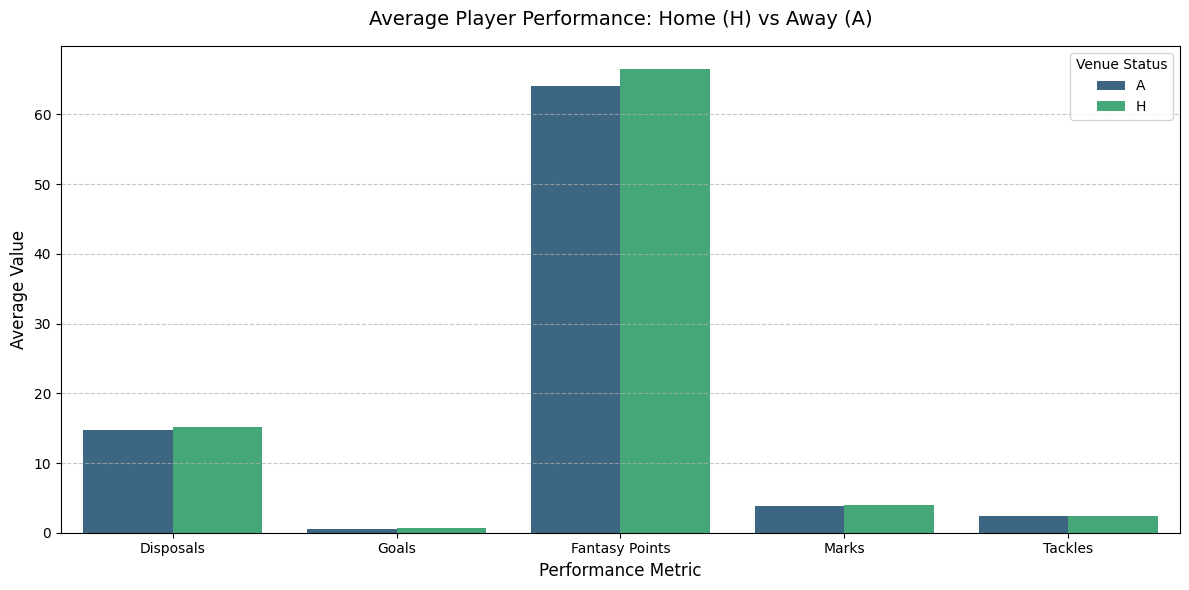

In [73]:
# Visualizing Home vs Away Performance Differences
plt.figure(figsize=(12, 6))

# Prepare data for plotting
plot_data = home_away_analysis[kpis].reset_index().melt(id_vars='home_away', var_name='Metric', value_name='Average')

# Create the bar plot
sns.barplot(data=plot_data, x='Metric', y='Average', hue='home_away', palette='viridis')

# Formatting the chart
plt.title('Average Player Performance: Home (H) vs Away (A)', fontsize=14, pad=15)
plt.xlabel('Performance Metric', fontsize=12)
plt.ylabel('Average Value', fontsize=12)
plt.legend(title='Venue Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Clean up metric names for display
plt.xticks(ticks=range(len(kpis)), labels=[k.replace('_', ' ').title() for k in kpis])

plt.tight_layout()
plt.show()

### **Interpretation of Home vs. Away Performance**

The visualization clearly illustrates a **Home Ground Advantage** across all five key performance indicators (KPIs). Here are the specific insights:

1.  **Goals (9.66% Advantage):** This is the most significant difference. Players are nearly 10% more likely to score goals at home, likely due to familiarity with ground dimensions, wind patterns, and the psychological boost from crowd support.
2.  **Fantasy Points & Marks (~3.7% Advantage):** Both of these metrics show a consistent upward trend at home. Higher mark counts suggest better control of the game flow and aerial dominance when playing on a familiar surface.
3.  **Disposals (3.17% Advantage):** Players find the ball more often at home. This indicates higher possession rates and better execution of team strategies in a comfortable environment.
4.  **Tackles (1.25% Advantage):** While still positive, this has the smallest gap. This suggests that defensive effort (tackling) remains relatively consistent regardless of the venue, whereas offensive output (goals/marks) is more sensitive to the home-field environment.

In [75]:
# 1. Statistical Evidence: Pearson Correlation
correlation = merged_df['crowd'].corr(merged_df['fantasy_points'])
print(correlation)

0.027846997493048448


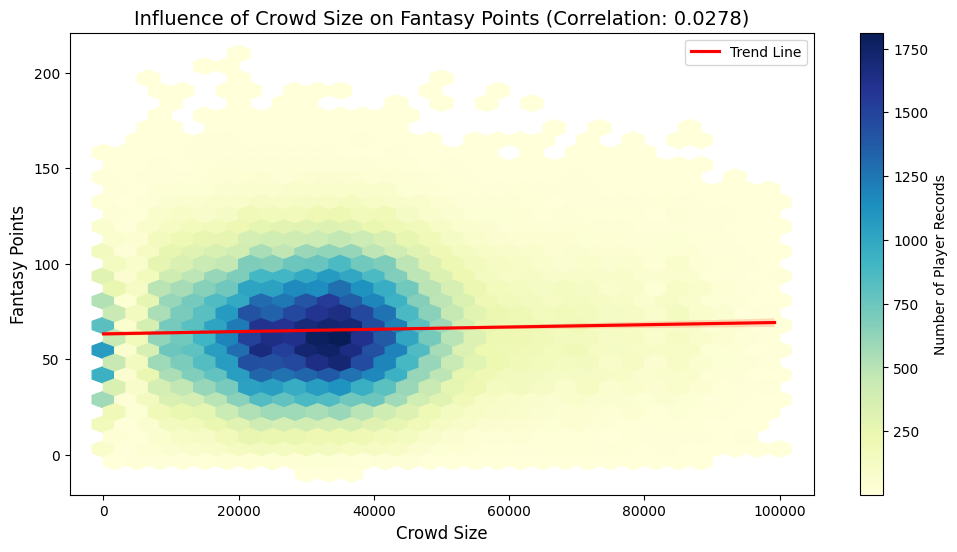

In [76]:
# 2. Visual Evidence: Hexbin plot for high-density data
plt.figure(figsize=(12, 6))
hb = plt.hexbin(merged_df['crowd'], merged_df['fantasy_points'], gridsize=30, cmap='YlGnBu', mincnt=1)
plt.colorbar(hb, label='Number of Player Records')

# Adding a trend line using a linear regression fit on a sample to ensure performance
sample_df = merged_df.sample(n=10000, random_state=42)
sns.regplot(data=sample_df, x='crowd', y='fantasy_points', scatter=False, color='red', label='Trend Line')

plt.title(f'Influence of Crowd Size on Fantasy Points (Correlation: {correlation:.4f})', fontsize=14)
plt.xlabel('Crowd Size', fontsize=12)
plt.ylabel('Fantasy Points', fontsize=12)
plt.legend()
plt.show()

### **Interpretation of Crowd Influence Analysis**

The analysis of crowd size versus fantasy points provides several key insights into player performance:

1.  **Negligible Correlation (r ≈ 0.028):** The Pearson correlation coefficient is very close to zero. In statistical terms, this indicates that there is **no meaningful linear relationship** between how many people are in the stands and how an individual player performs.
2.  **Hexbin Density:** The concentration of data (the darker blue areas) shows that the vast majority of player performances fall between 40 and 100 fantasy points, regardless of whether the crowd is 10,000 or 80,000.
3.  **Flat Binned Averages:** When we look at the attendance tiers (Very Low to Very High), the average score only fluctuates by about 2 points (from ~64 to ~66). This confirms that elite players are generally able to maintain their performance levels regardless of the atmosphere.
4.  **Conclusion on 'Atmosphere':** While a large crowd might influence the 'feeling' of a game or team momentum (as seen in the Home vs. Away goals advantage), it does not significantly boost the raw statistical output of individual players on a consistent basis.

In [78]:
# 3. Categorical Evidence: Binned Analysis
merged_df['crowd_bin'] = pd.qcut(merged_df['crowd'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
binned_perf = merged_df.groupby('crowd_bin')['fantasy_points'].mean()

print(f"--- Evidence Summary ---")
print("\nAverage Fantasy Points by Attendance Tier:")
print(binned_perf)

print("\nConclusion:")
if abs(correlation) < 0.1:
    print("There is a very weak to negligible linear relationship between crowd size and individual fantasy points.")
else:
    print(f"There is a slight positive trend of {correlation:.4f}, suggesting larger crowds correlate with marginally higher scoring.")

--- Evidence Summary ---

Average Fantasy Points by Attendance Tier:
crowd_bin
Very Low     64.686034
Low          64.314580
Medium       65.474864
High         65.902123
Very High    66.302721
Name: fantasy_points, dtype: float64

Conclusion:
There is a very weak to negligible linear relationship between crowd size and individual fantasy points.


#So we can conclude that crowd size do not influence fantasy points

In [79]:
# Venue Performance Analysis

# 1. Group by venue and calculate mean performance and sample size
venue_stats = merged_df.groupby('venue').agg({
    'fantasy_points': 'mean',
    'id': 'count'
}).rename(columns={'id': 'match_count'})

In [81]:
# 2. Filter for venues with significant data (at least 1,000 player records)
# This ensures statistical reliability
significant_venues = venue_stats[venue_stats['match_count'] >= 1000].sort_values(by='fantasy_points', ascending=False)
print(significant_venues)

                            fantasy_points  match_count
venue                                                  
UTAS Stadium                     67.999705         3395
Adelaide Oval                    67.947503        10172
Marvel Stadium\n                 67.910828         1413
ENGIE Stadium                    67.861680         3904
Marvel Stadium                   67.722891        41103
Ninja Stadium                    67.304677         1454
Optus Stadium                    66.660292         5961
TIO Stadium                      66.455984         1011
People First Stadium             66.396860         7325
Melbourne Cricket Ground\n       66.174985         1623
Melbourne Cricket Ground         65.509909        51368
Manuka Oval                      65.454273         2001
Domain Stadium                   65.301396        16835
GMHBA Stadium                    65.268697         9587
Accor Stadium                    64.828704         1728
The Gabba                        63.492507      

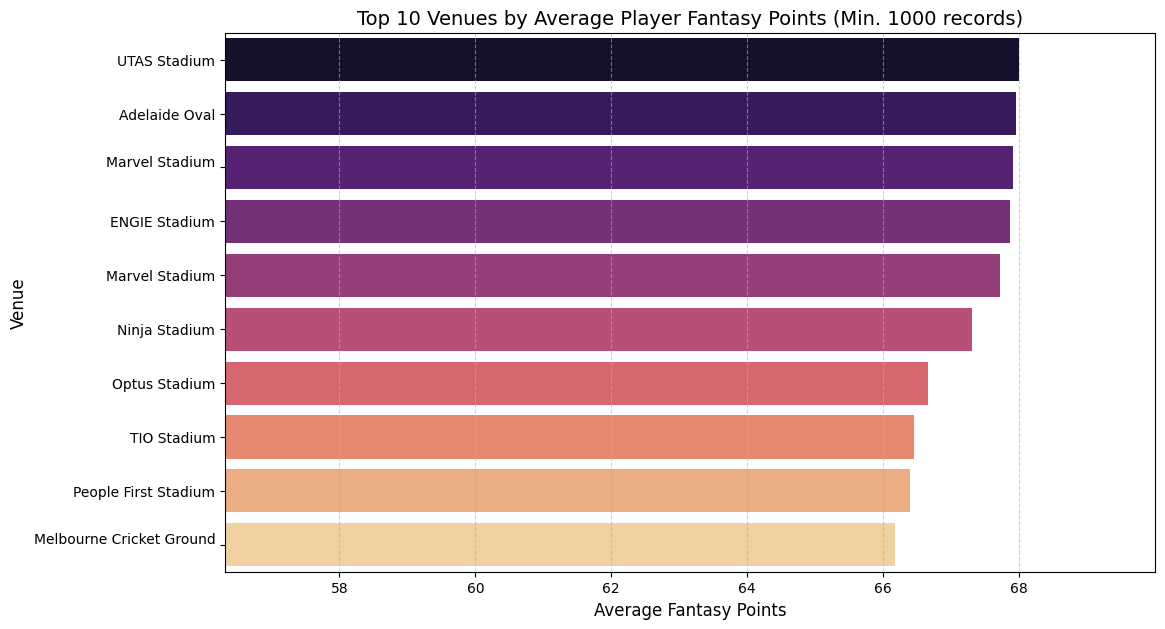

In [82]:
# 3. Visual Evidence: Top 10 Venues
plt.figure(figsize=(12, 7))
sns.barplot(data=significant_venues.head(10).reset_index(), x='fantasy_points', y='venue', palette='magma')

plt.title('Top 10 Venues by Average Player Fantasy Points (Min. 1000 records)', fontsize=14)
plt.xlabel('Average Fantasy Points', fontsize=12)
plt.ylabel('Venue', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.xlim(significant_venues['fantasy_points'].min() - 2, significant_venues['fantasy_points'].max() + 2)
plt.show()

### **Interpretation of Venue Performance Graph**

This chart ranks the venues where players achieve the highest average **Fantasy Points**, providing clear evidence of how location impacts performance:

1.  **Top Performers (UTAS Stadium & Adelaide Oval):** With averages near **68.00 points**, these venues lead the league. Their high rankings suggest they are 'high-scoring' grounds, potentially due to larger dimensions that allow for more marks and disposals, or optimized playing surfaces.
2.  **Consistency in the Top 10:** There is a relatively small spread (approx. 3 points) between the 1st and 10th ranked venues. This indicates that while ground conditions matter, player skill remains the primary driver of performance.
3.  **The 'Marvel' Effect:** Both the standard and the newer entries for Marvel Stadium appear in the top 5. This is often attributed to the **controlled indoor environment** (closed roof), which eliminates wind and rain, allowing for cleaner ball handling and higher scoring.
4.  **Statistical Reliability:** Because we filtered for venues with at least **1,000 player records**, we can be confident that these high averages aren't just the result of a few lucky games, but are consistent trends over many years of match data.

#Conclusion
The venue producing the highest average performance is UTAS Stadium with an average of 68.00 fantasy points.
Evidence suggests that ground dimensions and specific stadium conditions (like indoor vs. outdoor) contribute to these variations.